In [68]:
import random

In [69]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model
)
from pycaret.utils import version

In [70]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]

In [71]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("wine_spectator.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [72]:

unnamed_cols=df.filter(regex="Unnamed")
df = df.drop(categorical_cols, axis=1)
df = df.drop(extra_cols, axis=1)
df = df.drop(unnamed_cols, axis=1)
df = df.drop(other_ratings, axis=1)

df = df[id_cols+predictors+target_cols]
indices = list(df.index)
n_samples = len(indices)
train_samples = int(0.8 * n_samples)
test_samples = n_samples - train_samples
print(f"train_samples = {train_samples}")
print(f"test_samples = {test_samples}")
random.shuffle(indices)
pick_k_random_indices = random.sample(indices, train_samples)
not_picked_indices = set(indices).difference(pick_k_random_indices)
df_train = df.loc[pick_k_random_indices, :]
df_train_id = df_train[id_cols]
df_train = df_train.drop(id_cols, axis=1)
df_train = df_train.dropna(subset=target_cols, axis=0)

train_samples = 20
test_samples = 5


In [75]:
df_test = df.loc[not_picked_indices, :]
df_test_id = df_test[id_cols]
df_test_truth = df_test[target_cols]
df_test = df_test.drop(id_cols, axis=1)
df_test = df_test.drop(target_cols, axis=1)

In [76]:
print(list(df.describe()))

['productID', 'productStock', 'price', 'prodAlcoholPercent_percent', 'WS']


In [77]:
print("2. Initialize Setup")
reg1 = setup(
    data=df_train,
    target="WS",
    experiment_name='ws_from_meta',
    imputation_type='iterative',    
)

2. Initialize Setup


,Description,Value
0,Session id,1500
1,Target,WS
2,Target type,Regression
3,Original data shape,"(20, 4)"
4,Transformed data shape,"(20, 4)"
5,Transformed train set shape,"(14, 4)"
6,Transformed test set shape,"(6, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,iterative


In [78]:
print("3. Compare Baseline")

best_model = compare_models(fold=5)

3. Compare Baseline


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,07:25:07
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Linear Regression


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)


Processing:   0%|          | 0/77 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print("4. Create Model")
lr = create_model('lr')
lr = tune_model(lr, n_iter=5, optimize='RMSE')
evaluate_model(lr)

In [ ]:
rf = create_model('rf')
rf = tune_model(rf, n_iter=5, optimize='RMSE')
evaluate_model(rf)

In [ ]:
knn=create_model('knn')
knn = tune_model(knn, n_iter=5, optimize='RMSE')
evaluate_model(knn)

In [ ]:
print("5. Tune Hyperparameters")
lightgbm = create_model('lightgbm')
lightgbm = tune_model(lightgbm, n_iter=5, optimize='MAE')
evaluate_model(lightgbm)

In [ ]:
print("6. Ensemble Model")

In [ ]:
dt = create_model('dt')

In [ ]:
bagged_dt = ensemble_model(dt, n_estimators=50)

In [ ]:
boosted_dt = ensemble_model(dt, method='Boosting')

In [ ]:
print("7. Blend Models")

In [ ]:
list(models().index)

In [19]:
top_five = compare_models(n_select=5, fold=5, include=list(models().index))

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
dt,Decision Tree Regressor,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0980
rf,Random Forest Regressor,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1180
lightgbm,Light Gradient Boosting Machine,0.0000,0.0000,0.0001,1.0000,0.0000,0.0000,0.1080
et,Extra Trees Regressor,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1120
knn,K Neighbors Regressor,0.0006,0.0004,0.0121,0.9999,0.0001,0.0000,0.0980
gbr,Gradient Boosting Regressor,0.0736,0.0098,0.0980,0.9976,0.0011,0.0008,0.1120
ada,AdaBoost Regressor,0.6756,0.7977,0.8930,0.8044,0.0097,0.0074,0.0960
lar,Least Angle Regression,1.1190,1.8293,1.3523,0.5514,0.0145,0.0122,0.0900
br,Bayesian Ridge,1.1189,1.8294,1.3523,0.5514,0.0145,0.0122,0.0960
lr,Linear Regression,1.1190,1.8293,1.3523,0.5514,0.0145,0.0122,0.0940


In [20]:
blender = blend_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
3,0.0029,0.0001,0.0121,1.0000,0.0001,0.0000
4,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
5,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
6,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
7,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
8,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000


In [21]:
print("8. Stack Models")

8. Stack Models


In [22]:
stacker = stack_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
3,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
4,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
5,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
6,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
7,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
8,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000


In [23]:
print("9. Analyze Model")

9. Analyze Model


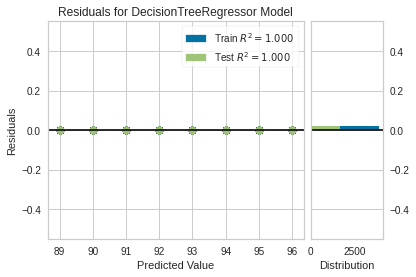

In [24]:
plot_model(dt)

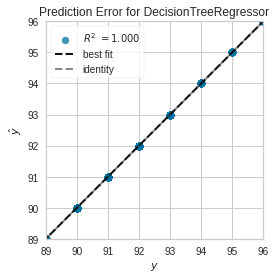

In [25]:
plot_model(dt, plot='error')

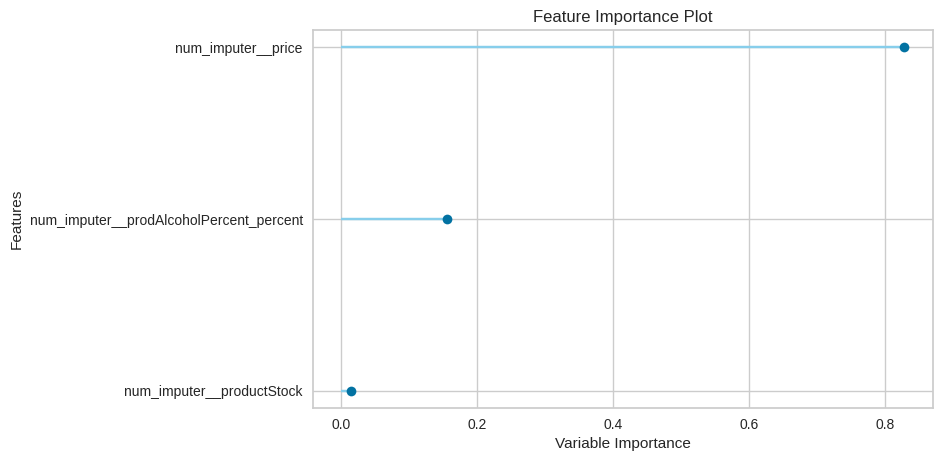

In [26]:
plot_model(dt, plot='feature')

In [27]:
evaluate_model(dt)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [28]:
print("10. Interpret Model")

10. Interpret Model


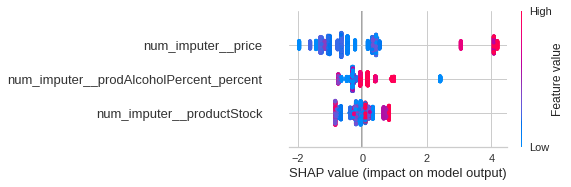

In [29]:
interpret_model(lightgbm)

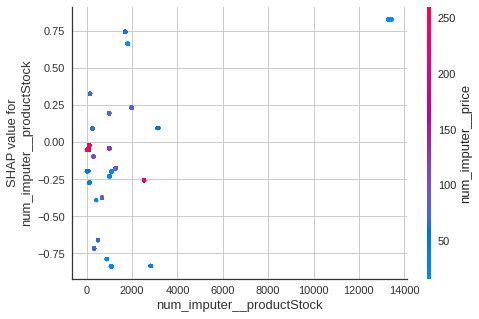

In [30]:
interpret_model(lightgbm, plot='correlation')

In [31]:
interpret_model(lightgbm, plot='reason', observation=12)

In [32]:
print("11. AutoML()")

11. AutoML()


In [33]:
best = automl(optimize='MAE')
print(best)

StackingRegressor(cv=5,
                  estimators=[('Decision Tree Regressor',
                               DecisionTreeRegressor(random_state=7636)),
                              ('Random Forest Regressor',
                               RandomForestRegressor(n_jobs=-1,
                                                     random_state=7636)),
                              ('Light Gradient Boosting Machine',
                               LGBMRegressor(random_state=7636)),
                              ('Extra Trees Regressor',
                               ExtraTreesRegressor(n_jobs=-1,
                                                   random_state=7636)),
                              ('K Neighbors Regressor',
                               KNeighborsRegressor(n_jobs=-1))],
                  final_estimator=LinearRegression(n_jobs=-1), n_jobs=-1,
                  passthrough=True)


In [34]:
print("12. Predict Model")

12. Predict Model


In [35]:
pred_holdouts = predict_model(lightgbm)
pred_holdouts.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.0000,0.0000,0.0001,1.0000,0.0000,0.0000


,productStock,price,prodAlcoholPercent_percent,WS,prediction_label
339,3162.0,59.990002,12.0,91.0,91.000028
6361,1699.0,49.990002,13.5,93.0,92.999974
4672,1803.0,14.980000,13.5,91.0,91.000028
6586,11.0,259.989990,14.0,96.0,95.999895
4079,90.0,159.990005,14.1,96.0,95.999895


In [36]:
predict_new = predict_model(best, data=df_test)
predict_new.head()

,productStock,price,prodAlcoholPercent_percent,prediction_label
0,2527.0,209.990005,14.5,95.000000
1,674.0,79.970001,12.0,90.003333
6,299.0,99.989998,12.0,91.996667
22,11.0,259.989990,14.0,96.000000
24,2819.0,36.990002,13.0,90.000000


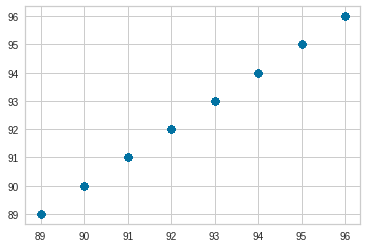

In [37]:
from matplotlib import pyplot as plt
plt.scatter(predict_new['prediction_label'],df_test_truth)

In [38]:
save_model(best, model_name='best-model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=/tmp/joblib),
          steps=[('iterative_imputer',
                  TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=7636),
                                                                  cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=7636),
                                                                                                               {}),
                                                                  categorical_indices=[],
                                                                  max_iter=5,
                                                                  num_estimator=LGBMRegressor(random_state=7636),
                                                                  num_estimator...
                                                 DecisionTreeRegressor(random_state=7636)),
                                                ('Random Forest Regressor',


In [39]:
loaded_bestmodel = load_model('best-model')
print(loaded_bestmodel)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('iterative_imputer',
                 TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=7636),
                                                                 cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=7636),
                                                                                                              {}),
                                                                 categorical_indices=[],
                                                                 max_iter=5,
                                                                 num_estimator=LGBMRegressor(random_state=7636),
                                                                 num_estimator...
                                                DecisionTreeRegressor(random_state=7636)),
                                

In [40]:
print(loaded_bestmodel[0])

TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=7636),
                                                cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=7636),
                                                                                             {}),
                                                categorical_indices=[],
                                                max_iter=5,
                                                num_estimator=LGBMRegressor(random_state=7636),
                                                num_estimator_prepare_for_categoricals_type=(LGBMRegressor(random_state=7636),
                                                                                             {}),
                                                random_state=7636,
                                                skip_complete=True))


In [41]:
X_train = get_config('X_train')
X_train.head()

,productStock,price,prodAlcoholPercent_percent
198,11.0,54.990002,14.5
5083,3126.0,59.990002,12.0
5545,1803.0,14.980000,13.5
6603,324.0,69.989998,14.5
4855,997.0,119.989998,14.5
